In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Mall_Customers.csv')

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
X = dataset.iloc[:, [3,4]].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

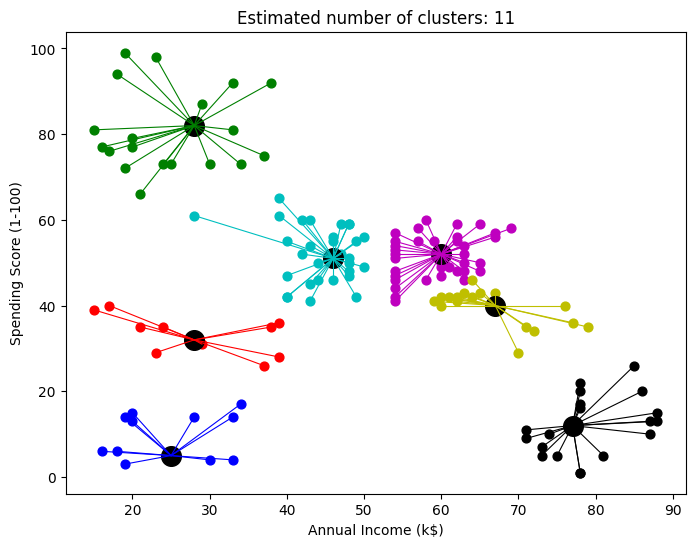

In [15]:
from sklearn.cluster import AffinityPropagation
aff = AffinityPropagation(random_state=5)
labels = aff.fit_predict(X)

# Cluster centers
cluster_centers = aff.cluster_centers_
cluster_center_indices = aff.cluster_centers_indices_

# Number of clusters
n_clusters = len(cluster_centers)

plt.figure(figsize=(8,6))

colors = ['b','g','r','c','m','y','k']

for k, col in zip(range(n_clusters), colors):

    members = labels == k

    center = cluster_centers[k]

    # Plot data points
    plt.scatter(X[members,0],
                X[members,1],
                color=col,
                s=40)

    # Plot cluster center
    plt.scatter(center[0],
                center[1],
                color='black',
                marker='o',
                s=200)

    # Draw line from every point to cluster center
    for x in X[members]:
        plt.plot([center[0], x[0]],
                 [center[1], x[1]],
                 color=col,
                 linewidth=0.8)

plt.title(f'Estimated number of clusters: {n_clusters}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()


In [16]:
from sklearn.cluster import AffinityPropagation
aff = AffinityPropagation(random_state=5)
y_aff=aff.fit_predict(X)

In [17]:
supervised = pd.DataFrame(dataset)

In [18]:
supervised['cluster_group']=y_aff
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,2
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,9
196,197,Female,45,126,28,10
197,198,Male,32,126,74,9
198,199,Male,32,137,18,10


E:\anaconda3\envs\aiml\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


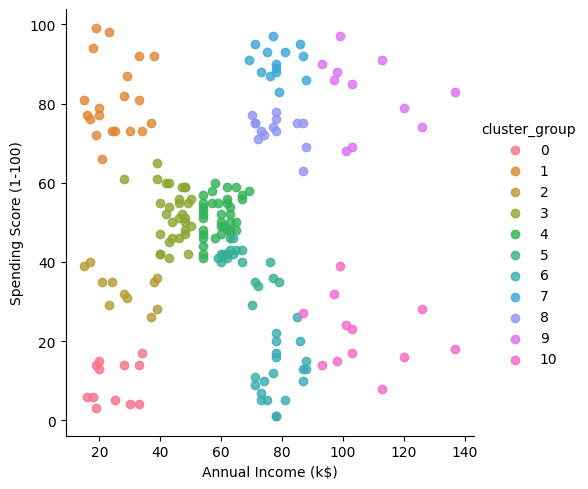

In [19]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3],
y=supervised.columns[4], hue=supervised.columns[5],
 fit_reg=False, legend=True, legend_out=True)